# AI Urban Growth Monitoring System

## Project Overview

Rapid urbanization is transforming cities worldwide, often at the expense of natural ecosystems. Monitoring urban expansion is essential for sustainable urban planning, environmental conservation, and policy development.

This project presents an AI-powered Urban Growth Monitoring System that analyzes land-cover changes in Bengaluru, India, between 2016 and 2024 using Sentinel-2 satellite imagery and Google Earth Engine. Built-up areas were identified using the Normalized Difference Built-up Index (NDBI), while vegetation loss was assessed using the Normalized Difference Vegetation Index (NDVI).

The system quantifies urban expansion, estimates vegetation loss, visualizes spatial changes, and automatically generates a professional urban growth assessment report using Google's Gemini AI. The workflow demonstrates how GeoAI can support evidence-based decision-making for urban planners, environmental agencies, and researchers.

In [35]:
# Import Libraries
!pip install geemap earthengine-api google-genai -q

In [36]:
# Authenticate GEE
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='active-venture-461910-q0')

print("Earth Engine Connected")

Earth Engine Connected


In [37]:
# Load Bengaluru Boundary
bangalore = (
    ee.FeatureCollection("FAO/GAUL/2015/level2")
    .filter(ee.Filter.eq('ADM1_NAME', 'Karnataka'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Bangalore Urban'))
)

print(bangalore.size().getInfo())

1


In [38]:
Map = geemap.Map()

Map.centerObject(bangalore, 10)

Map.addLayer(
    bangalore,
    {},
    "Bangalore Urban"
)

Map

Map(center=[12.942246211440619, 77.58684946919364], controls=(WidgetControl(options=['position', 'transparent_…

In [39]:
# Load Sentinel-2 Images
s2_2016 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(bangalore)
    .filterDate('2016-01-01', '2016-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .median()
    .clip(bangalore)
)

print("2016 Image Loaded")

2016 Image Loaded


In [40]:
s2_2024 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(bangalore)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .median()
    .clip(bangalore)
)

print("2024 Image Loaded")

2024 Image Loaded


In [41]:
# RGB Visualization
rgb = {
    'bands':['B4','B3','B2'],
    'min':0,
    'max':3000
}

Map = geemap.Map()

Map.centerObject(bangalore, 10)

Map.addLayer(s2_2016, rgb, "2016 RGB")

Map.addLayer(s2_2024, rgb, "2024 RGB")

Map

Map(center=[12.942246211440619, 77.58684946919364], controls=(WidgetControl(options=['position', 'transparent_…

In [42]:
# NDBI 2016
ndbi_2016 = s2_2016.normalizedDifference(['B11', 'B8']).rename('NDBI')

# NDBI 2024
ndbi_2024 = s2_2024.normalizedDifference(['B11', 'B8']).rename('NDBI')

In [43]:
# Visualize NDBI
ndbi_vis = {
    'min': -0.5,
    'max': 0.5,
    'palette': ['green', 'yellow', 'red']
}

Map = geemap.Map()
Map.centerObject(bangalore, 10)

Map.addLayer(ndbi_2016, ndbi_vis, 'NDBI 2016')
Map.addLayer(ndbi_2024, ndbi_vis, 'NDBI 2024')

Map

Map(center=[12.94224621144063, 77.58684946919362], controls=(WidgetControl(options=['position', 'transparent_b…

In [44]:
## Built-up Area Extraction
builtup_2016 = ndbi_2016.gt(0.1)
builtup_2024 = ndbi_2024.gt(0.1)

In [45]:
Map = geemap.Map()
Map.centerObject(bangalore, 10)

Map.addLayer(
    builtup_2016.selfMask(),
    {'palette': ['blue']},
    'Built-up 2016'
)

Map.addLayer(
    builtup_2024.selfMask(),
    {'palette': ['red']},
    'Built-up 2024'
)

Map

Map(center=[12.94224621144063, 77.58684946919362], controls=(WidgetControl(options=['position', 'transparent_b…

In [46]:
## Area Calculation Function
def calculate_area(image):

    area = (
        image.selfMask()
        .multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=bangalore.geometry(),
            scale=10,
            maxPixels=1e13
        )
    )

    return list(area.getInfo().values())[0] / 1e6

In [47]:
# Built-up Area Statistics
builtup_area_2016 = calculate_area(builtup_2016)

builtup_area_2024 = calculate_area(builtup_2024)

print(f"Built-up Area 2016: {builtup_area_2016:.2f} km²")
print(f"Built-up Area 2024: {builtup_area_2024:.2f} km²")

Built-up Area 2016: 436.18 km²
Built-up Area 2024: 1072.73 km²


In [48]:
# Urban Growth Analysis
urban_growth = builtup_area_2024 - builtup_area_2016

growth_percent = (
    urban_growth / builtup_area_2016
) * 100

print(f"Urban Growth Area: {urban_growth:.2f} km²")
print(f"Urban Growth Rate: {growth_percent:.2f}%")

Urban Growth Area: 636.55 km²
Urban Growth Rate: 145.94%


In [49]:
urban_growth_map = builtup_2024.And(
    builtup_2016.Not()
)

In [50]:
## New Urban Area
new_urban_area = calculate_area(urban_growth_map)

print(f"New Urban Area: {new_urban_area:.2f} km²")

New Urban Area: 746.06 km²


In [51]:
ndvi_2016 = s2_2016.normalizedDifference(
    ['B8','B4']
).rename('NDVI')

In [52]:
ndvi_2024 = s2_2024.normalizedDifference(
    ['B8','B4']
).rename('NDVI')

In [53]:
veg_2016 = ndvi_2016.gt(0.4)

veg_2024 = ndvi_2024.gt(0.4)

In [54]:
veg_loss = veg_2016.And(
    veg_2024.Not()
)

In [55]:
veg_loss_area = calculate_area(veg_loss)

print(
    f"Vegetation Loss: {veg_loss_area:.2f} km²"
)

Vegetation Loss: 801.94 km²


In [56]:
Map = geemap.Map()

Map.centerObject(bangalore,10)

Map.addLayer(
    veg_loss.selfMask(),
    {'palette':['yellow']},
    'Vegetation Loss'
)

Map

Map(center=[12.942246211440619, 77.58684946919364], controls=(WidgetControl(options=['position', 'transparent_…

In [57]:
# Display Urban Growth Map
Map = geemap.Map()

Map.centerObject(bangalore, 10)

Map.addLayer(
    builtup_2016.selfMask(),
    {'palette': ['gray']},
    'Built-up 2016'
)

Map.addLayer(
    urban_growth_map.selfMask(),
    {'palette': ['red']},
    'Urban Growth (2016–2024)'
)

Map.addLayer(
    bangalore,
    {},
    'Study Area'
)

Map

Map(center=[12.942246211440619, 77.58684946919364], controls=(WidgetControl(options=['position', 'transparent_…

In [58]:
# Calculate New Urban Area
new_urban_area = calculate_area(
    urban_growth_map
)

print(
    f"New Urban Area: {new_urban_area:.2f} km²"
)

New Urban Area: 746.06 km²


In [59]:
ndvi_2016 = s2_2016.normalizedDifference(
    ['B8','B4']
).rename('NDVI')

ndvi_2024 = s2_2024.normalizedDifference(
    ['B8','B4']
).rename('NDVI')

In [60]:
veg_2016 = ndvi_2016.gt(0.4)

veg_2024 = ndvi_2024.gt(0.4)

In [61]:
import pandas as pd

results = pd.DataFrame({
    "Metric":[
        "Built-up Area 2016",
        "Built-up Area 2024",
        "Urban Growth",
        "Urban Growth Rate",
        "New Urban Area",
        "Vegetation Loss"
    ],
    "Value":[
        "436.18 km²",
        "1072.73 km²",
        "636.55 km²",
        "145.94 %",
        "746.06 km²",
        "801.94 km²"
    ]
})

results

,Metric,Value
0,Built-up Area 2016,436.18 km²
1,Built-up Area 2024,1072.73 km²
2,Urban Growth,636.55 km²
3,Urban Growth Rate,145.94 %
4,New Urban Area,746.06 km²
5,Vegetation Loss,801.94 km²


In [62]:
results.to_csv(
    "Urban_Growth_Results.csv",
    index=False
)

print("Dashboard exported")

Dashboard exported


In [63]:
from google.colab import userdata

API_KEY = userdata.get("GEMINI_API_KEY")

print(API_KEY[:10])

AQ.Ab8RN6I


In [64]:
from google import genai
from google.colab import userdata

API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=API_KEY)

print("Gemini Connected")

Gemini Connected


In [65]:
report = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=f"""

Generate a professional urban growth assessment report.

Study Area: Bengaluru Urban District
Period: 2016-2024

Results:

Built-up Area 2016: 436.18 km²

Built-up Area 2024: 1072.73 km²

Urban Growth Area: 636.55 km²

Urban Growth Rate: 145.94%

New Urban Area: 746.06 km²

Vegetation Loss: 801.94 km²

Include:

1. Executive Summary
2. Urban Growth Analysis
3. Environmental Impact
4. Key Findings
5. Recommendations

"""
)

print(report.text)

## Urban Growth Assessment Report: Bengaluru Urban District

**Study Period:** 2016-2024

**Date:** October 26, 2024

**Prepared For:** [Relevant Authority/Stakeholder, e.g., Department of Urban Development, Karnataka]

**Prepared By:** [Your Name/Organization]

---

### 1. Executive Summary

This report provides a comprehensive assessment of urban growth within the Bengaluru Urban District over the eight-year period from 2016 to 2024. The findings reveal an unprecedented and rapid urbanization trend, characterized by a substantial expansion of built-up areas and a corresponding significant loss of natural vegetation cover. The built-up area has increased by an astonishing 145.94%, from 436.18 km² in 2016 to 1072.73 km² in 2024, representing an absolute growth of 636.55 km². This rapid conversion has led to a documented loss of 801.94 km² of vegetation. These figures highlight immense pressure on the region's natural resources, infrastructure, and urban sustainability, necessitating im

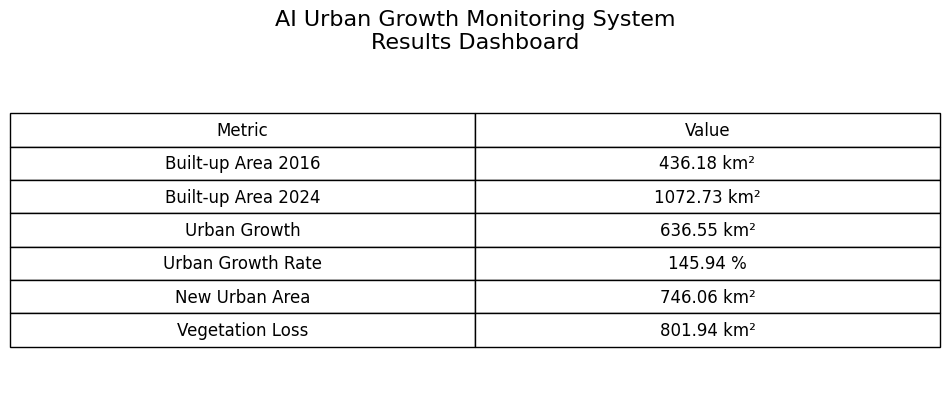

In [68]:
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

plt.title(
    "AI Urban Growth Monitoring System\nResults Dashboard",
    fontsize=16,
    pad=20
)

# Create the 'outputs' directory if it doesn't exist
output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(
    os.path.join(output_dir, "results_dashboard.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

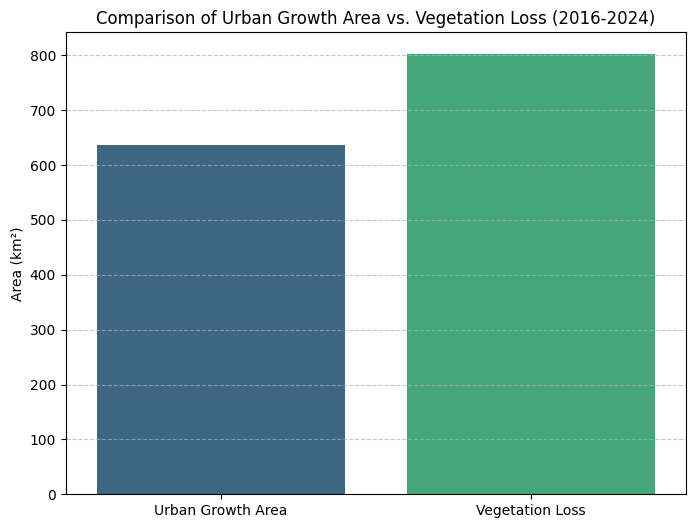

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a DataFrame for the comparison
comparison_data = pd.DataFrame({
    'Metric': ['Urban Growth Area', 'Vegetation Loss'],
    'Value (km²)': [urban_growth, veg_loss_area]
})

# Create the bar chart
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Value (km²)', data=comparison_data, palette='viridis')
plt.title('Comparison of Urban Growth Area vs. Vegetation Loss (2016-2024)')
plt.ylabel('Area (km²)')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation

The comparison highlights the environmental impact of rapid urban expansion in Bengaluru between 2016 and 2024.

The analysis indicates that approximately **636.55 km²** of new urban development occurred during the study period, while nearly **801.94 km²** of vegetation was lost. The vegetation loss exceeds the mapped urban expansion, suggesting that urban growth has affected surrounding green spaces and natural landscapes beyond the newly developed built-up areas.

These findings emphasize the importance of sustainable urban planning strategies that balance infrastructure development with environmental conservation.

# Conclusion

This project successfully demonstrated an end-to-end GeoAI workflow for monitoring urban growth using satellite imagery, cloud-based geospatial processing, and generative AI.

### Key Findings

- Built-up area increased from **436.18 km²** in 2016 to **1072.73 km²** in 2024.
- Urban expansion covered approximately **636.55 km²**, representing a **145.94% increase** over the study period.
- Approximately **746.06 km²** of newly developed urban land was identified.
- Vegetation loss reached **801.94 km²**, indicating substantial environmental changes associated with urbanization.

The integration of Sentinel-2 imagery, Google Earth Engine, NDBI, NDVI, and Gemini AI enabled efficient detection, quantification, visualization, and reporting of urban growth patterns.

This workflow can support urban planners, government agencies, environmental organizations, and researchers by providing timely and data-driven insights for sustainable city development. The methodology is scalable and can be adapted to monitor urban growth in other cities and regions worldwide.